# 03 — Evaluating a model the benchmark has never seen

**Time:** ~30 minutes · **This is the hands-on.**

Notebook 02 scored the four authors the benchmark ships with, and showed how
much of a count can hang on one line of the evaluator. Now we use the
benchmark for what it was built for: **testing a model that took no part in
its construction.**

Our submission is **Claude Opus 4.8**, released after CQBench was built. Its
200 answers already sit in `data/predictions/claude.jsonl` — treat them as the
output of a model you ran this morning. We follow the flow any CQBench user
follows:

> **validate** → **evaluate** → **compare**

In [2]:
import sys, pathlib, time, os, subprocess
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import cqhandson as ch
from cqhandson import paths, runner, figures
from cqhandson.metrics import compare_submission

ch.style()
pd.set_option("display.width", 200)

ENVIRONMENT = dict(os.environ) | {"SEMGREP_ENABLE_VERSION_CHECK": "0"}

## Step 1 — validate the submission

Before any analyzer runs, CQBench checks the file itself: one JSON object per
task, `task_id` as the only join key, no unknown ids, no duplicates. This is
the stock CLI.

In [3]:
print(subprocess.run(
    [sys.executable, "-m", "cqbench", "validate-submission",
     "--tasks", str(paths.TASKS),
     "--predictions", str(paths.PREDICTIONS / "claude.jsonl")],
    cwd=paths.VENDOR, capture_output=True, text=True, env=ENVIRONMENT
).stdout.strip())

{"tasks": 200, "predictions": 200}


`{"tasks": 200, "predictions": 200}` — every task answered.

Notice what validation does **not** do: it never looks at the code. A file of
200 empty strings validates fine. Missing answers are legal too — they stay in
the denominator and score as empty output, so you cannot quietly shrink your
own test set.

## Step 2 — evaluate

200 tasks, one author, about **25 seconds**.

In [4]:
rows = runner.evaluate(paths.PREDICTIONS / "claude.jsonl",
                       output=paths.LIVE / "claude.jsonl")
print(f"\n{len(rows)} tasks scored")

  semgrep     200 files      5.5s
  pylint      200 files      5.8s
  structure   200 files      2.0s
  ------------------------------------    13.4s total

200 tasks scored


That is the entire submission flow. If you had generated 200 completions from
your own model this morning, you would now be done.

In [6]:
results = ch.results_frame()
display(ch.results_source().to_frame())

,source
Human,your run
ChatGPT,your run
DeepSeek-Coder,your run
Qwen2.5-Coder,your run
Claude Opus 4.8,your run


## Step 3 — the first question: did it even answer?

Before any quality judgement, a mechanical one. Every task names a function
and its parameters; the benchmark checks that the answer contains *that*
function, and that it is more than a stub.

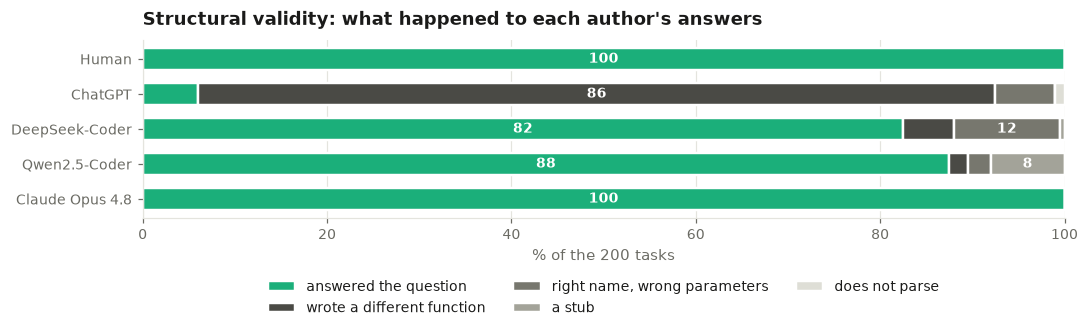

In [7]:
figures.plot_validity(results);

**Read the ChatGPT row before anything else.** On 86% of tasks it wrote a
function with a *different name*. Its code parses and is often reasonable — it
simply is not the function that was asked for.

Why so systematically? Many of these signatures are **methods** taken from
real classes — `def install_key(self, key_data)`. `gpt-3.5-turbo` reliably
rewrites them as free-standing functions it prefers.

That single behaviour will drag every later ChatGPT number down. When a
composite metric collapses, look here first: **you may be measuring
instruction-following, not code quality.**

Claude clears this gate on all 200 — and so does the human reference, but for
a different reason. **The human's 100% is guaranteed by construction**: a task
only entered CQBench if its human implementation parses, exposes the requested
signature, and is structurally non-trivial. That bar is an entry requirement
for the task, not a measurement of the author. Claude's 100% is a result; the
human's is a tautology. Any chart that shows both has to be read that way.

## Step 4 — the scoreboard

Four rates, one panel each. The dashed line is the human reference in every
panel: that is the bar a submission is trying to reach.

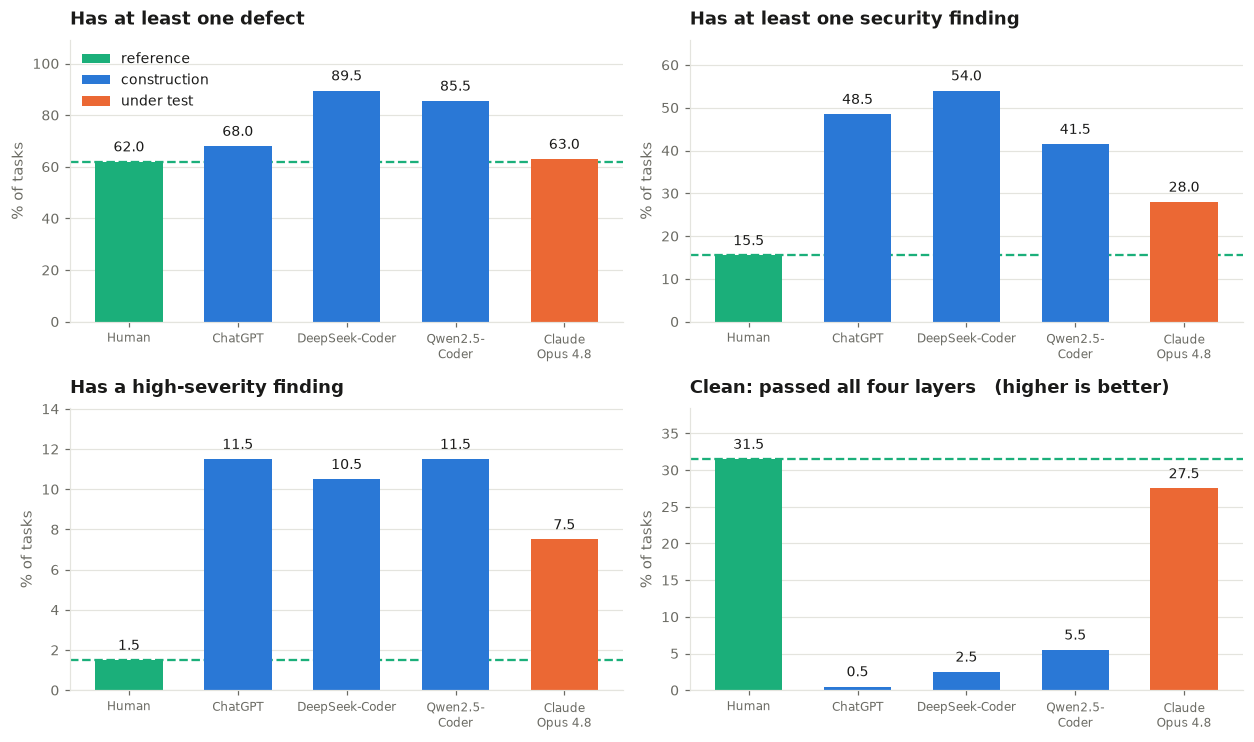

In [8]:
figures.plot_scoreboard(results);

The submission is clean on **27.5%** of these tasks. On its own that number
says nothing — it needs the scale the other bars give it:

* against the three models that **built** the benchmark (0.5%, 2.5%, 5.5%) it
  looks transformative, and that comparison is close to worthless: these tasks
  exist *because* those models failed them;
* against the **human reference** (31.5%) it is slightly behind, and that is
  the comparison that carries information.

## Step 5 — compare, and ask whether the differences are real

CQBench ships `cqbench compare`. It merges the submission with each baseline
**task by task**, then bootstraps the paired difference 10,000 times.

Pairing is the point: every author answered the *same* 200 tasks, so we
subtract per task instead of comparing two independent percentages. That
removes task difficulty from the comparison entirely.

In [9]:
print(subprocess.run(
    [sys.executable, "-m", "cqbench", "compare",
     "--submission", str(paths.LIVE / "claude.jsonl"),
     *sum([["--baseline", str(paths.results_dir() / f"{b}.jsonl")]
           for b in ch.BASELINES], []),
     "--output", str(paths.RESULTS / "comparison.csv")],
    cwd=paths.VENDOR, capture_output=True, text=True, env=ENVIRONMENT
).stdout.strip())

{"comparisons": 40}


The numbers are easier to read as a picture. Each row is the submission minus
one baseline; the dot is the difference, the bar is the 95% interval.

**A bar that touches the vertical line at zero is a difference the data does
not support.** That is the whole idea — you do not need to know what a
confidence interval is to read it.

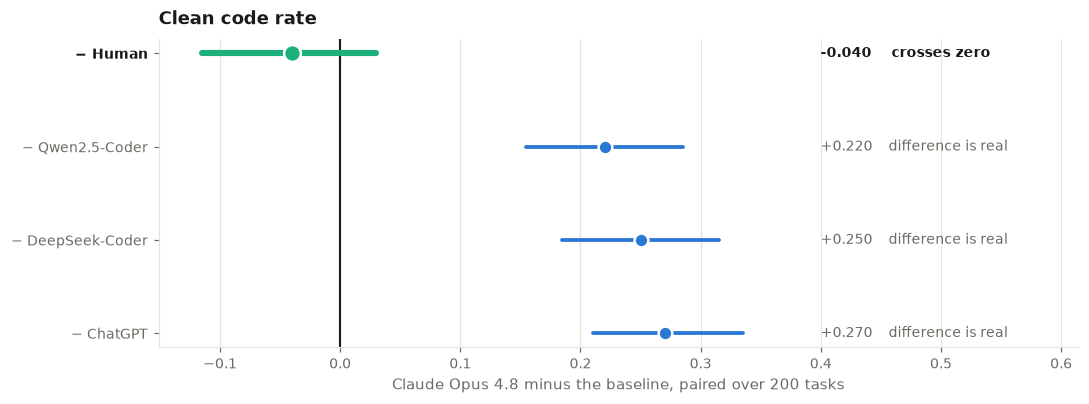

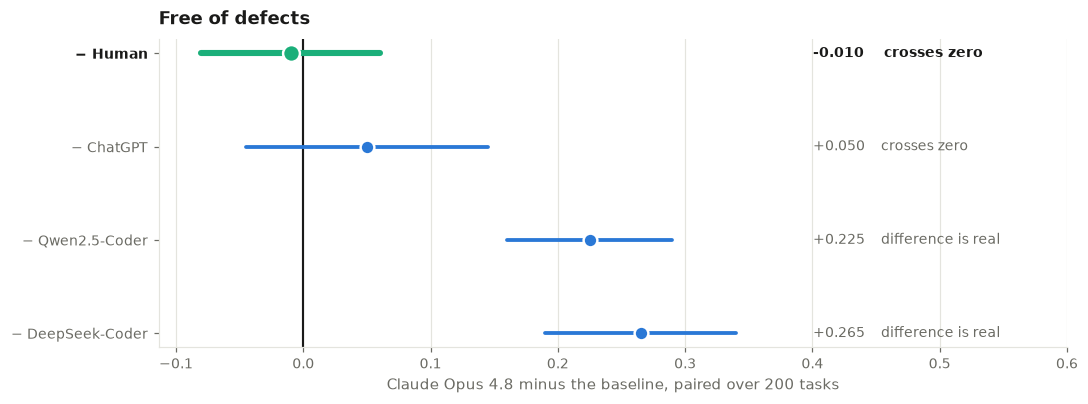

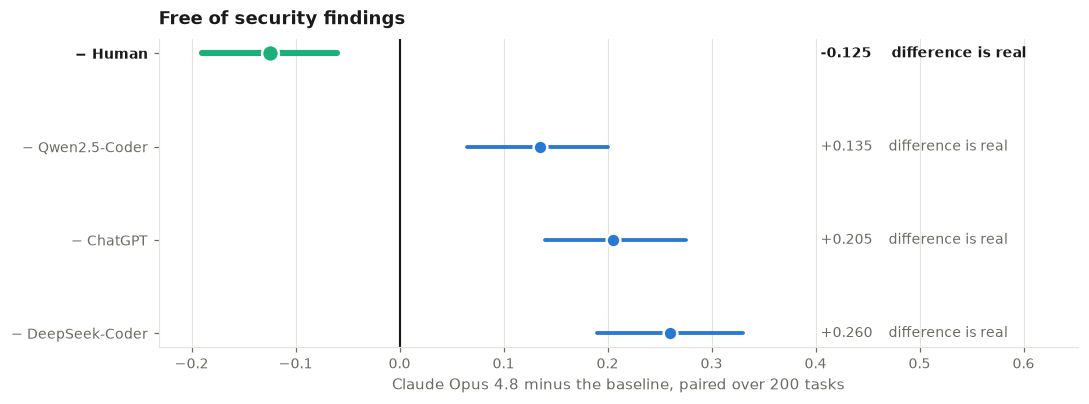

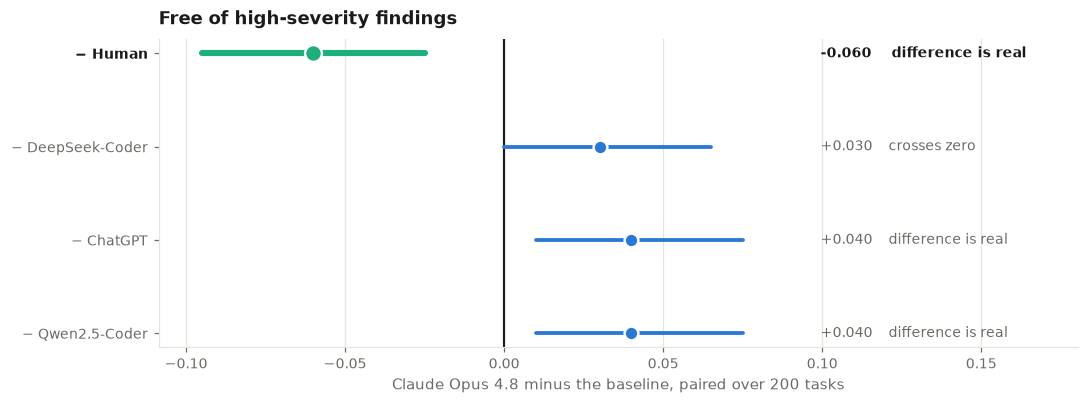

In [10]:
for metric, title in [
    ("clean_strict_at_1", "Clean code rate"),
    ("defect_free_rate", "Free of defects"),
    ("vulnerability_free_rate", "Free of security findings"),
    ("high_severity_free_rate", "Free of high-severity findings"),
]:
    figures.plot_forest(compare_submission(results, metric), title,
                        save=f"forest_{metric}")

Ignore the three blue rows in every chart — the submission beats the models
that built the benchmark, as it must. **The aqua row is the result:**

| | vs the human reference |
|---|---|
| clean code rate | **level** — the interval crosses zero |
| free of defects | **level** — crosses zero |
| free of security findings | **worse**, clearly |
| free of high-severity findings | **worse**, clearly |

A frontier model has closed the maintainability gap to human code on these
tasks and has **not** closed the security gap. Whatever changed between 2023
and 2026 fixed one and not the other.

## Step 6 — does the benchmark still bite?

The sharpest objection to a failure-derived benchmark: *you built it from
three models' failures, so of course those three fail it. Does it have any
force against a model that took no part?*

Half of our tasks carry a **consensus weakness class** — a specific CWE that
two 2023–24 models both produced, fixed at selection time, years before Claude
existed. Does Claude trip that same class?

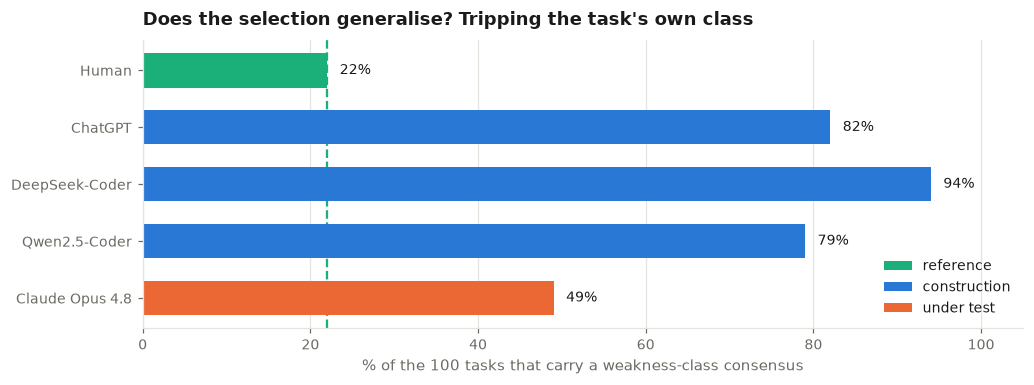

In [11]:
figures.plot_consensus(results, ch.load_tasks());

The three construction models sit near the ceiling, as they must — they
defined these classes. The **human reference**, also outside the construction,
trips them on 22%.

**Claude: 49%.** More than double the human rate on the same tasks. The tasks
elicit not merely findings but the *same class* of finding from a model
outside the selection. That is the strongest available answer to the "you only
measured your own construction set" objection — and it is why a
failure-derived benchmark is worth keeping.

---
## Takeaways

1. **Validate, evaluate, compare.** Three commands, and the third is the one
   that turns a number into a claim.
2. **Beating the models that built the benchmark is not a result.** Only the
   human row is news.
3. **A bar that crosses zero is not a difference.** The forest plot says it
   without any statistics vocabulary.
4. **A composite metric can collapse for the wrong reason** — check structural
   validity before you rank anything.

Next: `04_where_the_differences_are.ipynb` — what the code actually looks like.